In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

infile = r'C:\OEAS805\HW2\International_Coastal_Cleanup.csv'
data = pd.read_csv(infile, thousands = ',', low_memory = False)
data.head()

,Area,Date,Cigarette Butts,"Food Wrappers (candy, chips, etc.)",Take Out/Away Containers (Plastic),Take Out/Away Containers (Foam),Bottle Caps (Plastic),Bottle Caps (Metal),Lids (Plastic),"Straws, Stirrers",...,Tampons/Tampon Applicators,Personal Hygiene (Clean Swell),Foam Pieces,Glass Pieces,Plastic Pieces,Total Items Collected,Total Pounds of Litter Collected,Number of Volunteers,Volunteer Hours,Number of Miles
0,Ocean View Beach Park,10/27/2023,40,0,3,0,0,0,0,5,...,0,0,0,0,32,85.0,13,6,6.0,0.50
1,Lakewood Park,10/21/2023,20,64,16,18,107,12,79,31,...,1,0,121,0,121,1073.0,300,12,24.0,1.00
2,Plum Point Park,10/08/2023,7,30,2,6,29,2,7,15,...,0,0,18,11,19,337.0,90,10,30.0,0.25
3,Lafayette Park & Lavalette Boat Ramp,10/07/2023,220,166,19,55,76,42,24,17,...,0,0,198,76,188,1866.0,65,6,12.0,1.00
4,Barraud Park,10/07/2023,800,486,38,15,142,2488,36,149,...,0,0,31,15,13,5238.0,30,28,42.0,2.00


In [33]:
data.size
# 53 variables, 4081 cells of data, 5 rows of data

4081

In [38]:
data.info()
data['Area'].unique()
#combination of 3 data types, strings, floats, and integers across 36 different sites

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 53 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Area                                       77 non-null     str    
 1   Date                                       77 non-null     str    
 2   Cigarette Butts                            77 non-null     int64  
 3   Food Wrappers (candy, chips, etc.)         77 non-null     int64  
 4   Take Out/Away Containers (Plastic)         77 non-null     int64  
 5   Take Out/Away Containers (Foam)            77 non-null     int64  
 6   Bottle Caps (Plastic)                      77 non-null     int64  
 7   Bottle Caps (Metal)                        77 non-null     int64  
 8   Lids (Plastic)                             77 non-null     int64  
 9   Straws, Stirrers                           77 non-null     int64  
 10  Forks, Knives, Spoons                  

<StringArray>
[                                                  'Ocean View Beach Park',
                                                           'Lakewood Park',
                                                         'Plum Point Park',
                                    'Lafayette Park & Lavalette Boat Ramp',
                                                            'Barraud Park',
                        'The Academy Of International Studies At Rosemont',
                                                       'Harbor Park (ERT)',
                                                         'Ocean View Park',
                                     'East Ocean View (1300 - 1900 Block)',
                               'Bayview Elementary/East Bayview Boulevard',
                                                      'ODU/Lamberts Point',
                                              'East Ocean View Rec Center',
                                                         'East Ocean View'

In [35]:
data.isna().sum()
#NO,nan data

Area                                         0
Date                                         0
Cigarette Butts                              0
Food Wrappers (candy, chips, etc.)           0
Take Out/Away Containers (Plastic)           0
Take Out/Away Containers (Foam)              0
Bottle Caps (Plastic)                        0
Bottle Caps (Metal)                          0
Lids (Plastic)                               0
Straws, Stirrers                             0
Forks, Knives, Spoons                        0
Beverage Bottles (Plastic)                   0
Beverage Bottles (Glass)                     0
Beverage Cans                                0
Grocery Bags (Plastic)                       0
Other Plastic Bags                           0
Paper Bags                                   0
Cups, Plates (Paper)                         0
Cups, Plates (Plastic)                       0
Cups, Plates (Foam)                          0
Fishing Buoys, Pots & Traps                  0
Fishing Net &

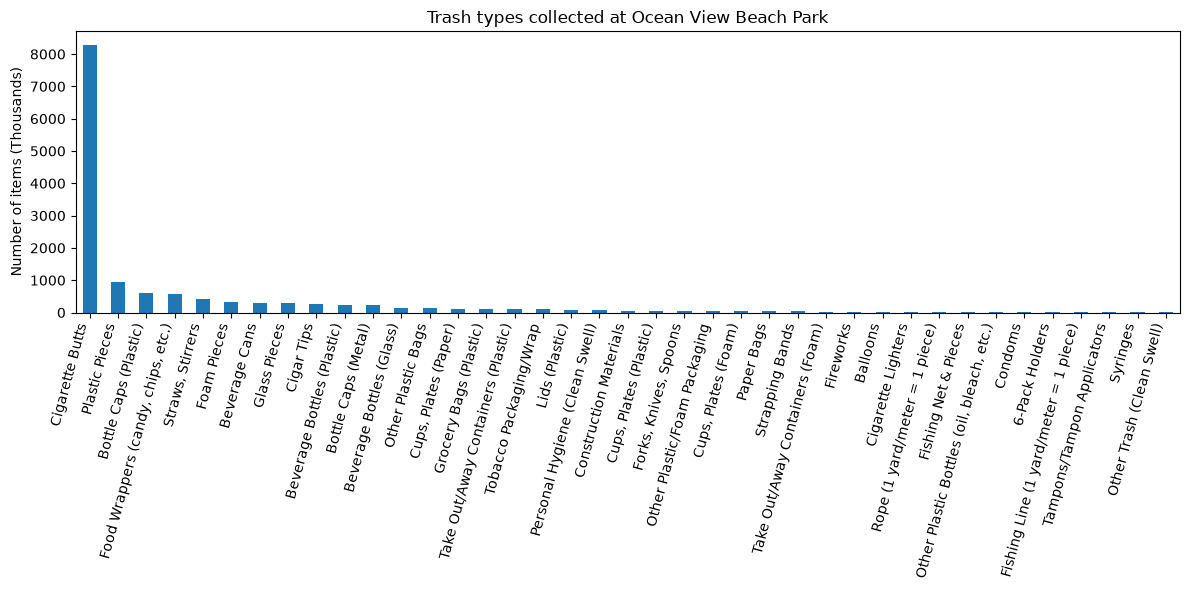

In [36]:
site_name = 'Ocean View Beach Park'
site = data[data['Area'] == site_name]

site_trash = site.loc[:, 'Cigarette Butts':'Plastic Pieces'].sum()
site_trash = site_trash[site_trash > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
site_trash.plot(kind='bar')
plt.ylabel('Number of items (Thousands)')
plt.title(f'Trash types collected at {site_name}')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

In [39]:
#*AI disclosure: The code in the cell below for computing descriptive statistics 
#(mean, median, standard deviation, min, max, IQR, and skew) was generated with 
#assistance from Claude (Opus 5.5), an AI model by Anthropic, accessed September 26, 2026 
#via claude.ai. I selected the variables and verified the output.*

summary_cols = ['Total Pounds of Litter Collected', 'Volunteer Hours', 'Number of Miles']

stats = pd.DataFrame({
    'mean':   data[summary_cols].mean(),
    'median': data[summary_cols].median(),
    'std':    data[summary_cols].std(),
    'min':    data[summary_cols].min(),
    'max':    data[summary_cols].max(),
    'IQR':    data[summary_cols].quantile(0.75) - data[summary_cols].quantile(0.25),
    'skew':   data[summary_cols].skew()
}).round(2)
stats

,mean,median,std,min,max,IQR,skew
Total Pounds of Litter Collected,200.56,80.0,379.65,0.0,2545.0,150.0,4.15
Volunteer Hours,37.37,22.0,57.04,0.0,396.0,29.0,4.11
Number of Miles,1.53,1.0,1.49,0.0,10.0,1.0,3.36


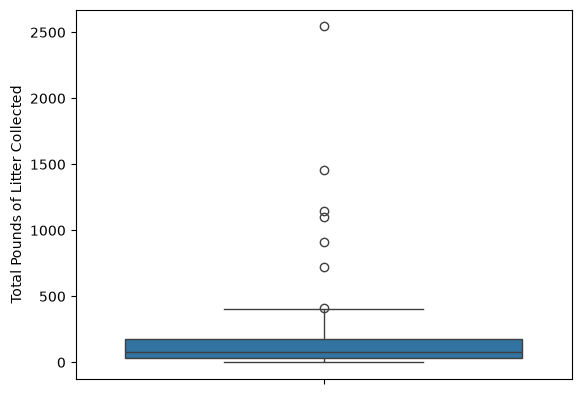

,Area,Date,Cigarette Butts,"Food Wrappers (candy, chips, etc.)",Take Out/Away Containers (Plastic),Take Out/Away Containers (Foam),Bottle Caps (Plastic),Bottle Caps (Metal),Lids (Plastic),"Straws, Stirrers",...,Tampons/Tampon Applicators,Personal Hygiene (Clean Swell),Foam Pieces,Glass Pieces,Plastic Pieces,Total Items Collected,Total Pounds of Litter Collected,Number of Volunteers,Volunteer Hours,Number of Miles
50,Barraud Park,09/30/2017,3639,1203,40,106,549,6269,79,106,...,0,0,528,2806,1051,20544.0,2545,132,396.0,1.0
73,SPOT- Military Gardens,09/30/2016,63,2,0,0,9,0,0,2,...,0,0,0,0,25,196.0,1460,7,35.0,2.0
76,Willoughby Spit,09/30/2016,386,59,41,25,127,0,93,146,...,0,59,0,0,289,1918.0,1150,42,126.0,2.0
20,Barraud Park,10/16/2021,2724,778,18,21,780,4332,77,368,...,1,3,47,754,1347,13269.5,1100,87,174.0,3.0
55,Lambert's Point (ODU Service Learning Group),09/30/2017,1003,944,80,46,214,160,109,166,...,14,33,156,1112,1458,7892.0,915,178,222.5,10.0
60,Willoughby Spit,09/30/2017,252,66,29,29,87,60,58,72,...,5,0,81,198,270,2093.0,725,38,114.0,1.0
24,Harbor Park (ERT),09/25/2021,438,382,52,66,177,36,86,67,...,2,22,308,120,860,4626.0,408,52,104.0,1.5
32,Harbor Park (ERT),10/05/2019,482,301,38,53,143,44,86,133,...,1,0,293,34,631,4062.0,405,29,43.5,1.0
49,Willoughby Spit,09/30/2018,780,339,68,52,155,231,74,156,...,0,24,488,65,0,4052.0,390,11,16.5,4.0
53,East Oceanview Community Park,09/30/2017,118,397,46,22,246,66,31,187,...,1,0,12,0,16,1936.0,345,9,22.5,1.0


In [46]:
# The data above seems to contain outliers, lets visualize
sns.boxplot(y=data['Total Pounds of Litter Collected'])
plt.show()

data.nlargest(10, 'Total Pounds of Litter Collected')

# Barraud Park seems to be the most littered without context of hours/volunteers required with a total mass of 2545 pounds of litter.


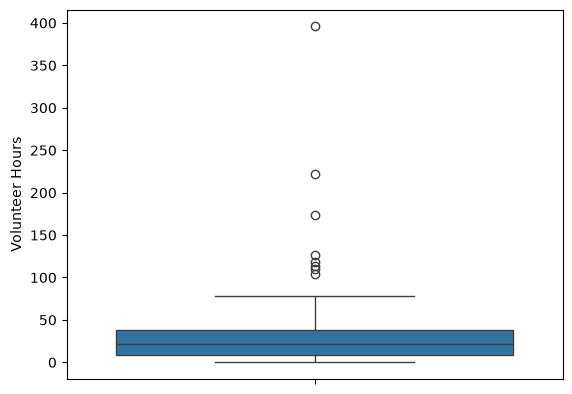

,Area,Date,Cigarette Butts,"Food Wrappers (candy, chips, etc.)",Take Out/Away Containers (Plastic),Take Out/Away Containers (Foam),Bottle Caps (Plastic),Bottle Caps (Metal),Lids (Plastic),"Straws, Stirrers",...,Tampons/Tampon Applicators,Personal Hygiene (Clean Swell),Foam Pieces,Glass Pieces,Plastic Pieces,Total Items Collected,Total Pounds of Litter Collected,Number of Volunteers,Volunteer Hours,Number of Miles
50,Barraud Park,09/30/2017,3639,1203,40,106,549,6269,79,106,...,0,0,528,2806,1051,20544.0,2545,132,396.0,1.0
55,Lambert's Point (ODU Service Learning Group),09/30/2017,1003,944,80,46,214,160,109,166,...,14,33,156,1112,1458,7892.0,915,178,222.5,10.0
20,Barraud Park,10/16/2021,2724,778,18,21,780,4332,77,368,...,1,3,47,754,1347,13269.5,1100,87,174.0,3.0
76,Willoughby Spit,09/30/2016,386,59,41,25,127,0,93,146,...,0,59,0,0,289,1918.0,1150,42,126.0,2.0
56,Norfolk Collegiate (Lafayette Park - Boat Ramp),09/30/2017,618,607,27,34,285,200,50,95,...,8,0,54,217,711,4037.0,270,59,118.0,1.0
60,Willoughby Spit,09/30/2017,252,66,29,29,87,60,58,72,...,5,0,81,198,270,2093.0,725,38,114.0,1.0
10,Harbor Park (ERT),10/22/2022,1119,269,90,42,354,27,73,135,...,4,6,218,246,680,4551.0,20,44,110.0,1.0
24,Harbor Park (ERT),09/25/2021,438,382,52,66,177,36,86,67,...,2,22,308,120,860,4626.0,408,52,104.0,1.5
45,Barraud Park,09/30/2018,699,629,33,23,313,828,10,127,...,0,2093,750,694,7415,14830.0,295,39,78.0,2.0
68,East Oceanview Community Park,09/30/2016,323,43,20,3,42,0,8,5,...,0,0,0,0,114,818.0,180,19,57.0,1.0


In [47]:
sns.boxplot(y=data['Volunteer Hours'])
plt.show()

data.nlargest(10, 'Volunteer Hours')
#Now we get a little more context, Barraud Park also took the largest amount of volunteer hours with 396.3 hours of work.

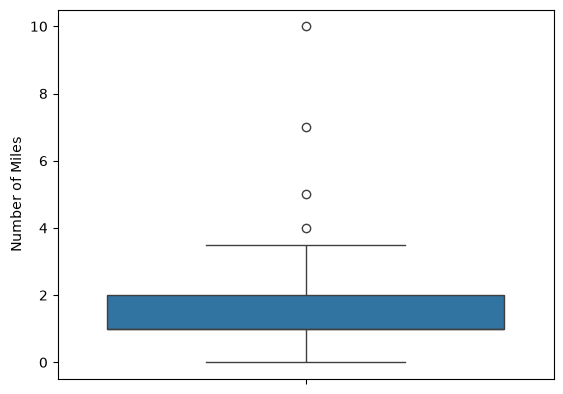

,Area,Date,Cigarette Butts,"Food Wrappers (candy, chips, etc.)",Take Out/Away Containers (Plastic),Take Out/Away Containers (Foam),Bottle Caps (Plastic),Bottle Caps (Metal),Lids (Plastic),"Straws, Stirrers",...,Tampons/Tampon Applicators,Personal Hygiene (Clean Swell),Foam Pieces,Glass Pieces,Plastic Pieces,Total Items Collected,Total Pounds of Litter Collected,Number of Volunteers,Volunteer Hours,Number of Miles
55,Lambert's Point (ODU Service Learning Group),09/30/2017,1003,944,80,46,214,160,109,166,...,14,33,156,1112,1458,7892.0,915,178,222.5,10.0
13,Bayview Elementary/East Bayview Boulevard,10/15/2022,56,233,3,5,36,8,10,21,...,0,24,1,291,116,988.0,25,26,52.0,7.0
35,Old Dominion University,10/05/2019,383,60,20,1,39,33,14,47,...,2,0,66,54,111,1092.0,120,4,6.0,5.0
49,Willoughby Spit,09/30/2018,780,339,68,52,155,231,74,156,...,0,24,488,65,0,4052.0,390,11,16.5,4.0
14,ODU/Lamberts Point,10/09/2022,24,59,52,18,35,19,30,43,...,0,19,65,77,138,999.0,220,15,45.0,3.5
7,Ocean View Park,09/05/2023,123,17,4,2,47,36,14,22,...,1,0,20,0,0,401.0,0,1,2.0,3.0
20,Barraud Park,10/16/2021,2724,778,18,21,780,4332,77,368,...,1,3,47,754,1347,13269.5,1100,87,174.0,3.0
23,Lakewood Park,10/08/2021,67,22,3,3,49,17,0,35,...,2,0,0,0,93,419.0,120,8,16.0,3.0
43,Old Dominion University,10/13/2018,19,17,7,4,6,4,7,5,...,0,22,11,31,228,456.0,60,6,6.0,3.0
38,Bayview Elementary/East Bayview Boulevard,09/28/2019,140,213,2,0,23,2,6,18,...,1,0,4,4,52,550.0,20,5,5.0,2.5


In [53]:
sns.boxplot(y=data['Number of Miles'])
plt.show()
data.nlargest(10, 'Number of Miles')sns.boxplot(y=data['Number of Miles'])
plt.show()
data.nlargest(10, 'Number of Miles')
# Despite Barraud Park taking the most volunteer hours and most trash, it doesnt not fall within the larger outliers of miles surveyd. 

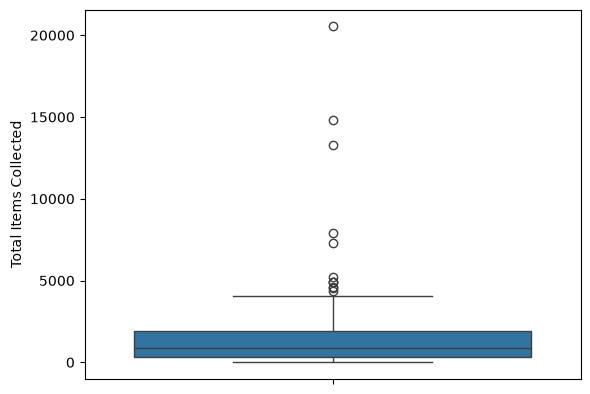

,Area,Date,Cigarette Butts,"Food Wrappers (candy, chips, etc.)",Take Out/Away Containers (Plastic),Take Out/Away Containers (Foam),Bottle Caps (Plastic),Bottle Caps (Metal),Lids (Plastic),"Straws, Stirrers",...,Tampons/Tampon Applicators,Personal Hygiene (Clean Swell),Foam Pieces,Glass Pieces,Plastic Pieces,Total Items Collected,Total Pounds of Litter Collected,Number of Volunteers,Volunteer Hours,Number of Miles
50,Barraud Park,09/30/2017,3639,1203,40,106,549,6269,79,106,...,0,0,528,2806,1051,20544.0,2545,132,396.0,1.0
45,Barraud Park,09/30/2018,699,629,33,23,313,828,10,127,...,0,2093,750,694,7415,14830.0,295,39,78.0,2.0
20,Barraud Park,10/16/2021,2724,778,18,21,780,4332,77,368,...,1,3,47,754,1347,13269.5,1100,87,174.0,3.0
55,Lambert's Point (ODU Service Learning Group),09/30/2017,1003,944,80,46,214,160,109,166,...,14,33,156,1112,1458,7892.0,915,178,222.5,10.0
39,Barraud Park,09/21/2019,3162,342,31,15,300,1384,56,176,...,0,0,30,258,371,7273.0,120,29,43.5,2.0
4,Barraud Park,10/07/2023,800,486,38,15,142,2488,36,149,...,0,0,31,15,13,5238.0,30,28,42.0,2.0
67,East Ocean View (1300 - 1800 Block),09/30/2016,3060,164,33,7,294,30,18,108,...,2,0,161,50,535,4904.0,60,2,4.0,1.0
70,Ocean View Beach Park,09/30/2016,3060,164,33,7,294,30,18,108,...,2,0,161,50,535,4904.0,240,15,45.0,1.0
9,Barraud Park,10/22/2022,1271,273,15,26,742,1589,6,90,...,0,6,96,0,97,4887.0,15,35,52.5,1.5
24,Harbor Park (ERT),09/25/2021,438,382,52,66,177,36,86,67,...,2,22,308,120,860,4626.0,408,52,104.0,1.5


In [55]:
sns.boxplot(y=data['Total Items Collected'])
plt.show()
data.nlargest(10, 'Total Items Collected')
# Barraud Park appears again among distinguishing it as one of the most littered places with the mos items collected in 2017 , and remaining as a top 10 for 6/10 times

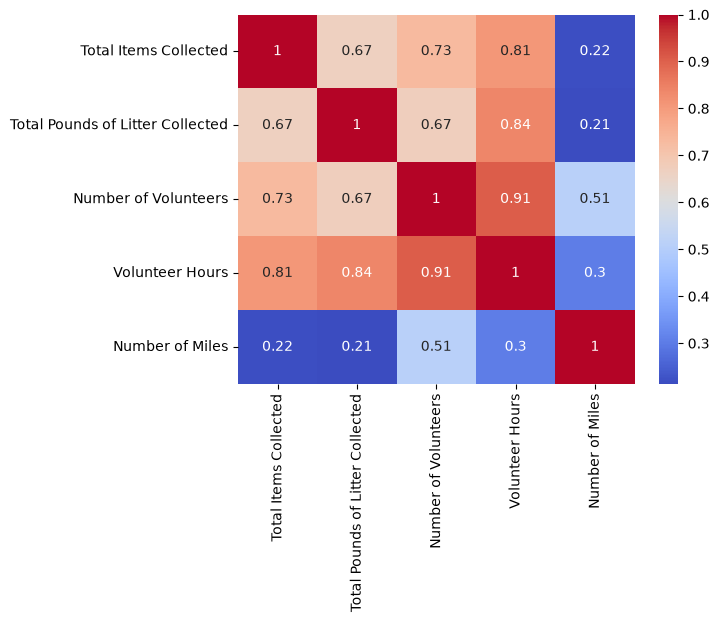

In [56]:
cols = ['Total Items Collected', 'Total Pounds of Litter Collected',
        'Number of Volunteers', 'Volunteer Hours', 'Number of Miles']

sns.heatmap(data[cols].corr(), annot=True, cmap='coolwarm')
plt.show()

# Volunteer hours correlates with Number of volunteers, this indicates that cleanups tend to last a similar amount of time.
#Total Pounds of litter is correlated heavily with volunteer hours, indicating more littered sites too more effort, or, dirtier sites drew larger groups with longer cleanup times.
#Miles vs Collection, distance does not correllate with litter collected, this suggests that density of litter varies vastly across sites.